1) First deal with necessary imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from shapely.geometry import Polygon, Point
from scipy.interpolate import RegularGridInterpolator
from scipy.sparse import diags as sp_diags, csr_matrix
from scipy.sparse.linalg import spsolve
from matplotlib.colors import ListedColormap, TwoSlopeNorm
import triangle as tr
from shapely.vectorized import contains
from scipy.ndimage import distance_transform_edt
from sklearn.model_selection import train_test_split
from shapely.geometry import box as sbox
import torch
import torch.nn as nn
import numpy as np


2) Pick our physical field. Want to deal with electrostatics. Temperature introduces more complicated time dependence, and fluid dynamics are a more difficult to get to converge + more complex boundary conditions. \
I think choosing gravitational fields would also be very interesting, but not immediately applicable to focus of Vinci, so will ignore the urge. ( Especially since gravitational potential is almost identical to electrostatic, but BC are nonexistent) \
Electrostatics are already rich and have interesting conditions, such as corner geometries. Could just choose an interesting geometry to train at various scales \
\
From here define our geometry. Currently choosing a rectangle with a rectangle cut out the middle. Introduces 4 corners and boundary conditions here. 


Triangle mesh:
  Vertices:  1,542
  Triangles: 2,900
  Segments:  184

Domain area: 0.9100  (expected 0.9100)

Boundary vertices:
  On outer wall:   140
  On obstacle:     44

Source term checks:
  ρ at + center (0.2, 0.6): 4.5115
  ρ at − center (0.8, 0.4): -1.5229
  ρ at center   (0.5, 0.5):  1.662176


/var/folders/__/68q69_j51cj16zb24xlwg1kw0000gn/T/ipykernel_76956/3152640766.py:168: UserWarning: The following kwargs were not used by contour: 'lw'
  ax.contour(XG, YG, RHO, levels=[0], colors='k', lw=1, linestyles='--')


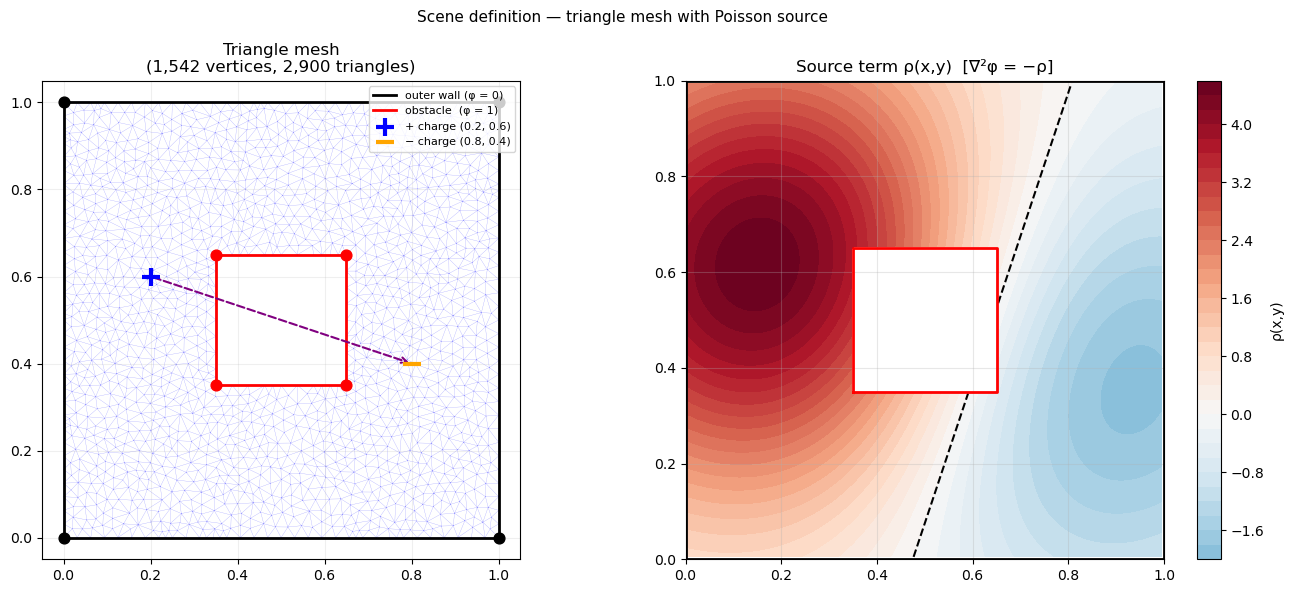

In [2]:

vertices = np.array([
    [0.00, 0.00],  
    [1.00, 0.00], 
    [1.00, 1.00],  
    [0.00, 1.00], 
    [0.35, 0.35],  
    [0.65, 0.35],  
    [0.65, 0.65],  
    [0.35, 0.65],  
])

segments = np.array([
    [0, 1], [1, 2], [2, 3], [3, 0],   
    [4, 5], [5, 6], [6, 7], [7, 4],  
])

holes = np.array([[0.50, 0.50]])   


pslg = {
    'vertices': vertices,
    'segments': segments,
    'holes':    holes,
}


mesh = tr.triangulate(pslg, 'pq30a0.0005D')

mesh_vertices  = mesh['vertices']  
mesh_triangles = mesh['triangles']   
mesh_segments  = mesh['segments']  

print(f"Triangle mesh:")
print(f"  Vertices:  {len(mesh_vertices):,}")
print(f"  Triangles: {len(mesh_triangles):,}")
print(f"  Segments:  {len(mesh_segments):,}")

outer    = vertices[:4].tolist()
obstacle = vertices[4:].tolist()
domain   = Polygon(shell=outer, holes=[obstacle])

def obstacle_bc(xy):
    """
    Spatially varying BC on obstacle boundary.
    φ = cos²(π * d_corner / (L_face/2))
    where d_corner = distance to nearest corner along the face.
    
    Corners at φ = 1, face midpoints at φ = 0.
    """
    x, y   = xy[:, 0], xy[:, 1]
    L      = 0.3      
    half_L = L / 2      

    vals = np.zeros(len(xy))

    for i, (xi, yi) in enumerate(xy):
        if np.abs(yi - 0.65) < 1e-6:         
            d = min(abs(xi - 0.35), abs(xi - 0.65))
        elif np.abs(yi - 0.35) < 1e-6:       
            d = min(abs(xi - 0.35), abs(xi - 0.65))
        elif np.abs(xi - 0.35) < 1e-6:       
            d = min(abs(yi - 0.35), abs(yi - 0.65))
        elif np.abs(xi - 0.65) < 1e-6:      
            d = min(abs(yi - 0.35), abs(yi - 0.65))
        else:
            d = 0.0  

        vals[i] = np.cos(np.pi * d / half_L) ** 2

    return vals

print(f"\nDomain area: {domain.area:.4f}  (expected {1.0 - 0.3**2:.4f})")

outer_vertex_indices    = set([0, 1, 2, 3])
obstacle_vertex_indices = set([4, 5, 6, 7])


outer_verts_xy    = mesh_vertices[
    [i for i in range(len(mesh_vertices))
     if domain.exterior.distance(Point(mesh_vertices[i])) < 1e-10]
]
obstacle_verts_xy = mesh_vertices[
    [i for i in range(len(mesh_vertices))
     if list(domain.interiors)[0].distance(Point(mesh_vertices[i])) < 1e-10]
]

print(f"\nBoundary vertices:")
print(f"  On outer wall:   {len(outer_verts_xy)}")
print(f"  On obstacle:     {len(obstacle_verts_xy)}")

# ── Source term ρ(x,y) ────────────────────────────────────────────────────────
CHARGE_AMPLITUDE = 5.0
CHARGE_SIGMA     = 0.35

POS_CENTER = (0.20, 0.60)
NEG_CENTER = (0.80, 0.40)

def source_term(x, y):
    """
    ρ(x,y) = A * [G+(x,y) - 0.5*G-(x,y)]
    PDE: ∇²φ = -ρ  (ε₀ = 1)
    Asymmetric amplitudes break diagonal symmetry deliberately.
    """
    def gaussian(x, y, cx, cy, sigma):
        return np.exp(-((x - cx)**2 + (y - cy)**2) / (2 * sigma**2))

    return CHARGE_AMPLITUDE * (
          gaussian(x, y, *POS_CENTER, CHARGE_SIGMA)
        - 0.5 * gaussian(x, y, *NEG_CENTER, CHARGE_SIGMA)
    )

print(f"\nSource term checks:")
print(f"  ρ at + center {POS_CENTER}: {source_term(*POS_CENTER):.4f}")
print(f"  ρ at − center {NEG_CENTER}: {source_term(*NEG_CENTER):.4f}")
print(f"  ρ at center   (0.5, 0.5):  {source_term(0.5, 0.5):.6f}")


fig, axes = plt.subplots(1, 2, figsize=(14, 6))


ax = axes[0]
ax.triplot(mesh_vertices[:, 0], mesh_vertices[:, 1],
           mesh_triangles, 'b-', lw=0.2, alpha=0.4)


ax.plot(*np.array(outer    + [outer[0]]).T,    'k-', lw=2,
        label='outer wall (φ = 0)')
ax.plot(*np.array(obstacle + [obstacle[0]]).T, 'r-', lw=2,
        label='obstacle  (φ = 1)')

ax.scatter(vertices[:4, 0], vertices[:4, 1], color='black', s=60, zorder=5)
ax.scatter(vertices[4:, 0], vertices[4:, 1], color='red',   s=60, zorder=5)


ax.scatter(*POS_CENTER, color='blue',   s=150, zorder=6,
           marker='+', linewidths=3, label=f'+ charge {POS_CENTER}')
ax.scatter(*NEG_CENTER, color='orange', s=150, zorder=6,
           marker='_', linewidths=3, label=f'− charge {NEG_CENTER}')

ax.annotate('', xy=NEG_CENTER, xytext=POS_CENTER,
            arrowprops=dict(arrowstyle='->', color='purple',
                            lw=1.5, linestyle='dashed'))

ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.set_aspect('equal')
ax.set_title(f'Triangle mesh\n({len(mesh_vertices):,} vertices, '
             f'{len(mesh_triangles):,} triangles)')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.2)


ax = axes[1]
Ng  = 200
xg  = np.linspace(0, 1, Ng)
yg  = np.linspace(0, 1, Ng)
XG, YG = np.meshgrid(xg, yg)
RHO = source_term(XG, YG)

for i in range(Ng):
    for j in range(Ng):
        if not domain.contains(Point(xg[i], yg[j])):
            RHO[j, i] = np.nan

vmax = np.nanmax(np.abs(RHO))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
cf   = ax.contourf(XG, YG, RHO, levels=40, cmap='RdBu_r', norm=norm)
plt.colorbar(cf, ax=ax, label='ρ(x,y)')
ax.contour(XG, YG, RHO, levels=[0], colors='k', lw=1, linestyles='--')
ax.plot(*np.array(outer    + [outer[0]]).T, 'k-', lw=2)
ax.plot(*np.array(obstacle + [obstacle[0]]).T, 'r-', lw=2)
ax.set_aspect('equal')
ax.set_title('Source term ρ(x,y)  [∇²φ = −ρ]')
ax.grid(True, alpha=0.3)

plt.suptitle('Scene definition — triangle mesh with Poisson source', fontsize=11)
plt.tight_layout()
plt.show()




3) we have a geometric setup for our problem. We now need to define 3 separate masks. \
First two define outer boundary potential being 0 and interior being 1 (fixed)  \
Third mask defines every other region, and will be free to update


/var/folders/__/68q69_j51cj16zb24xlwg1kw0000gn/T/ipykernel_76956/2524426334.py:45: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  in_obstacle_solid = contains(obstacle_solid, flat_x, flat_y).reshape(N, N)


Grid:    1024 x 1024  (1,048,576 points total)
Spacing: h = 0.000978  (resolves features down to ~0.0049)

Building masks...
Free interior points:  949,620
Obstacle fixed points: 94,864
Expected free ≈        952,341

Source term range:
  min ρ = -1.8703
  max ρ = 4.5757

Assembling sparse system...


/var/folders/__/68q69_j51cj16zb24xlwg1kw0000gn/T/ipykernel_76956/2524426334.py:46: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  in_domain         = contains(domain,         flat_x, flat_y).reshape(N, N)



BC value check (before solve):
  b at obstacle — min: 0.0000  max: 1.0000  mean: 0.2355
  unique values (sample): [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07]

Solving sparse system (direct)...
Done.

Sanity checks:
  Obstacle mean φ: 0.235450
  Exterior mean φ: 0.000000  (expected 0.0)
  Interior max φ:  0.980848
  Interior min φ:  -0.000000

Source term sign check:
  φ near + charge (0.2, 0.6): 0.332364  (should be elevated)
  φ near - charge (0.8, 0.4): 0.245640  (should be depressed)
  Difference: 0.086724  (should be positive)

Interpolator built.
  Query at (0.25, 0.50): φ = 0.326812
  Query at (0.75, 0.75): φ = 0.273439

BC variation checks:
  top face midpoint    (0.50, 0.65): φ = 0.000026  (expected ≈ 0.0)
  bottom face midpoint (0.50, 0.35): φ = 0.000026  (expected ≈ 0.0)
  left face midpoint   (0.35, 0.50): φ = 0.000026  (expected ≈ 0.0)
  corner (0.35, 0.35): φ = 0.999990  (expected ≈ 1.0)
  corner (0.65, 0.65): φ = 0.999990  (expected ≈ 1.0)


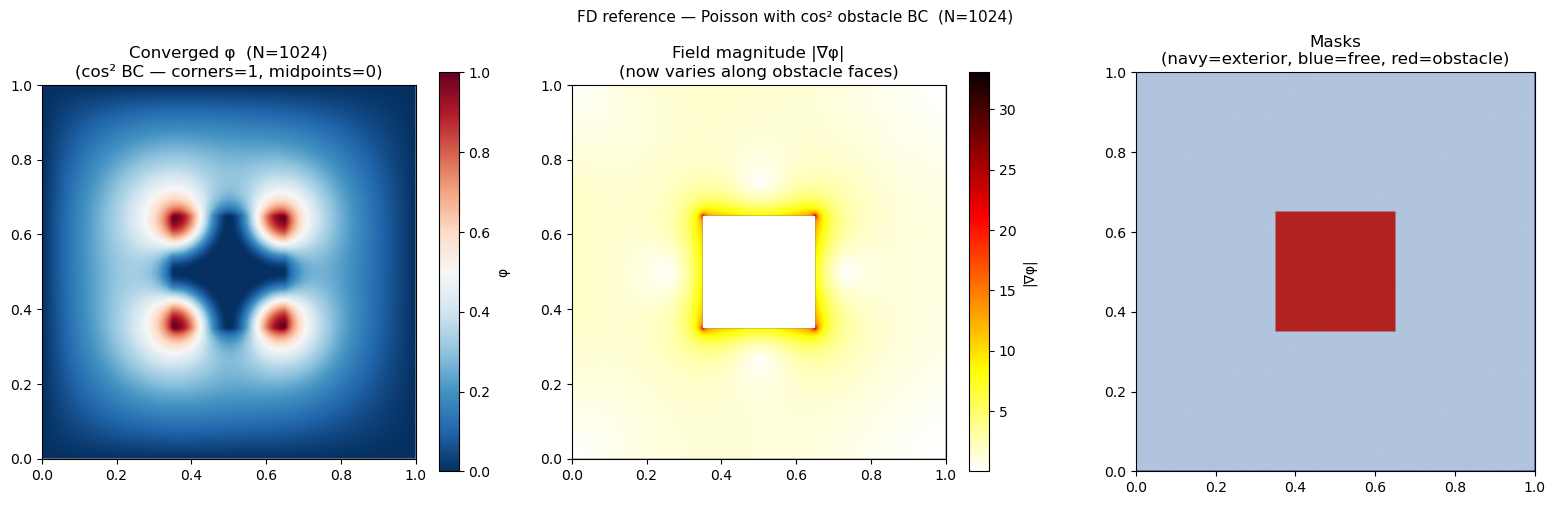

In [3]:
def nearest_face_bc(xy):
    """
    Spatially varying Dirichlet BC on obstacle boundary.
    For any point near/on the obstacle, compute φ based on
    distance to nearest corner.

    corners:   φ = 1
    midpoints: φ = 0
    """
    x, y   = xy[:, 0], xy[:, 1]
    vals   = np.zeros(len(xy))
    half_L = 0.15   # half of face length (obstacle is 0.3 wide)

    corners = [(0.35, 0.35), (0.65, 0.35),
               (0.65, 0.65), (0.35, 0.65)]

    for i in range(len(xy)):
        xi, yi   = x[i], y[i]
        d_corner = min(
            np.sqrt((xi - cx)**2 + (yi - cy)**2)
            for cx, cy in corners
        )
        d_clipped = min(d_corner, half_L)
        vals[i]   = np.cos(np.pi / 2 * d_clipped / half_L) ** 2

    return vals

N  = 1024
xs = np.linspace(0.0, 1.0, N)
ys = np.linspace(0.0, 1.0, N)
h  = xs[1] - xs[0]
XX, YY = np.meshgrid(xs, ys, indexing='ij')

print(f"Grid:    {N} x {N}  ({N**2:,} points total)")
print(f"Spacing: h = {h:.6f}  (resolves features down to ~{5*h:.4f})")


obstacle_solid = Polygon(vertices[4:8])

print("\nBuilding masks...")

flat_x = XX.ravel()
flat_y = YY.ravel()

in_obstacle_solid = contains(obstacle_solid, flat_x, flat_y).reshape(N, N)
in_domain         = contains(domain,         flat_x, flat_y).reshape(N, N)

near_obs = (
    (XX > 0.35 - 2*h) & (XX < 0.65 + 2*h) &
    (YY > 0.35 - 2*h) & (YY < 0.65 + 2*h)
)
on_boundary = np.zeros((N, N), dtype=bool)
for i, j in zip(*np.where(near_obs & ~in_obstacle_solid)):
    if obstacle_solid.boundary.distance(Point(xs[i], ys[j])) < h * 0.5:
        on_boundary[i, j] = True

mask_obstacle = in_obstacle_solid | on_boundary
mask_domain   = in_domain & ~mask_obstacle

print(f"Free interior points:  {mask_domain.sum():,}")
print(f"Obstacle fixed points: {mask_obstacle.sum():,}")
print(f"Expected free ≈        {int(domain.area / h**2):,}")

RHO = source_term(XX, YY)
RHO[~mask_domain] = 0.0

print(f"\nSource term range:")
print(f"  min ρ = {RHO[mask_domain].min():.4f}")
print(f"  max ρ = {RHO[mask_domain].max():.4f}")

print("\nAssembling sparse system...")

n_total       = N * N
flat_obstacle = mask_obstacle.ravel()
flat_domain   = mask_domain.ravel()
flat_exterior = ~flat_obstacle & ~flat_domain

diag_main = np.zeros(n_total)
diag_main[flat_obstacle] =  1.0
diag_main[flat_exterior] =  1.0
diag_main[flat_domain]   = -4.0

free    = flat_domain.astype(float)
diag_xp = free[:-N]
diag_xm = free[N:]
diag_yp = free[:-1]
diag_ym = free[1:]

A = sp_diags(
    [diag_main, diag_xp, diag_xm, diag_yp, diag_ym],
    [0,         N,       -N,       1,       -1      ],
    shape=(n_total, n_total),
    format='csr'
)

b = np.zeros(n_total)


obs_indices = np.where(flat_obstacle)[0]
obs_i       = obs_indices // N
obs_j       = obs_indices  % N
obs_xy      = np.stack([xs[obs_i], ys[obs_j]], axis=1)
b[flat_obstacle] = nearest_face_bc(obs_xy)

b[flat_exterior] = 0.0
b[flat_domain]   = -h**2 * RHO.ravel()[flat_domain]

print("\nBC value check (before solve):")
print(f"  b at obstacle — min: {b[flat_obstacle].min():.4f}  "
      f"max: {b[flat_obstacle].max():.4f}  "
      f"mean: {b[flat_obstacle].mean():.4f}")
print(f"  unique values (sample): {np.unique(b[flat_obstacle].round(2))[:8]}")

print("\nSolving sparse system (direct)...")
phi_flat = spsolve(A, b)
phi      = phi_flat.reshape(N, N)
print("Done.")

print(f"\nSanity checks:")
print(f"  Obstacle mean φ: {phi[mask_obstacle].mean():.6f}")
print(f"  Exterior mean φ: {phi[~mask_domain & ~mask_obstacle].mean():.6f}  (expected 0.0)")
print(f"  Interior max φ:  {phi[mask_domain].max():.6f}")
print(f"  Interior min φ:  {phi[mask_domain].min():.6f}")

i_pos = int(POS_CENTER[0] / h)
j_pos = int(POS_CENTER[1] / h)
i_neg = int(NEG_CENTER[0] / h)
j_neg = int(NEG_CENTER[1] / h)
print(f"\nSource term sign check:")
print(f"  φ near + charge {POS_CENTER}: {phi[i_pos, j_pos]:.6f}  (should be elevated)")
print(f"  φ near - charge {NEG_CENTER}: {phi[i_neg, j_neg]:.6f}  (should be depressed)")
print(f"  Difference: {phi[i_pos, j_pos] - phi[i_neg, j_neg]:.6f}  (should be positive)")

phi_reference = RegularGridInterpolator(
    (xs, ys),
    phi,
    method='linear',
    bounds_error=False,
    fill_value=None
)

print(f"\nInterpolator built.")
print(f"  Query at (0.25, 0.50): φ = {phi_reference([[0.25, 0.50]])[0]:.6f}")
print(f"  Query at (0.75, 0.75): φ = {phi_reference([[0.75, 0.75]])[0]:.6f}")


print(f"\nBC variation checks:")
print(f"  top face midpoint    (0.50, 0.65): φ = {phi_reference([[0.50, 0.65]])[0]:.6f}  (expected ≈ 0.0)")
print(f"  bottom face midpoint (0.50, 0.35): φ = {phi_reference([[0.50, 0.35]])[0]:.6f}  (expected ≈ 0.0)")
print(f"  left face midpoint   (0.35, 0.50): φ = {phi_reference([[0.35, 0.50]])[0]:.6f}  (expected ≈ 0.0)")
print(f"  corner (0.35, 0.35): φ = {phi_reference([[0.35, 0.35]])[0]:.6f}  (expected ≈ 1.0)")
print(f"  corner (0.65, 0.65): φ = {phi_reference([[0.65, 0.65]])[0]:.6f}  (expected ≈ 1.0)")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
phi_plot = phi.copy().astype(float)
phi_plot[~mask_domain & ~mask_obstacle] = np.nan
cf = ax.imshow(phi_plot.T, origin='lower', extent=[0, 1, 0, 1],
               cmap='RdBu_r', vmin=0, vmax=1)
plt.colorbar(cf, ax=ax, label='φ')
ax.set_title(f'Converged φ  (N={N})\n(cos² BC — corners=1, midpoints=0)')
ax.set_aspect('equal')

ax = axes[1]
dphi_dx, dphi_dy = np.gradient(phi, h, h)
grad_mag  = np.sqrt(dphi_dx**2 + dphi_dy**2)
grad_plot = grad_mag.copy().astype(float)
grad_plot[~mask_domain] = np.nan
cf2 = ax.imshow(grad_plot.T, origin='lower', extent=[0, 1, 0, 1],
                cmap='hot_r')
plt.colorbar(cf2, ax=ax, label='|∇φ|')
ax.set_title('Field magnitude |∇φ|\n(now varies along obstacle faces)')
ax.set_aspect('equal')

ax = axes[2]
mask_viz = np.zeros((N, N))
mask_viz[mask_domain]   = 1.0
mask_viz[mask_obstacle] = 2.0
cmap_mask = ListedColormap(['navy', 'lightsteelblue', 'firebrick'])
ax.imshow(mask_viz.T, origin='lower', extent=[0, 1, 0, 1],
          cmap=cmap_mask, vmin=0, vmax=2)
ax.set_title('Masks\n(navy=exterior, blue=free, red=obstacle)')
ax.set_aspect('equal')

plt.suptitle(f'FD reference — Poisson with cos² obstacle BC  (N={N})', fontsize=11)
plt.tight_layout()
plt.show()


In [4]:
# Diagnostic — how much does the source term actually matter?
print(f"Source term stats:")
print(f"  max |ρ|: {np.abs(RHO[mask_domain]).max():.4f}")
print(f"  mean |ρ|: {np.abs(RHO[mask_domain]).mean():.6f}")

print(f"\nField stats:")
print(f"  φ range: [{phi[mask_domain].min():.4f}, {phi[mask_domain].max():.4f}]")
print(f"  φ near + charge: {phi[i_pos, j_pos]:.6f}")
print(f"  φ near - charge: {phi[i_neg, j_neg]:.6f}")
print(f"  Difference: {phi[i_pos, j_pos] - phi[i_neg, j_neg]:.6f}")

# Also compute what fraction of the field variance is from the source
b_poisson = b.copy()
b_laplace_test = b.copy()
b_laplace_test[flat_domain] = 0.0   # zero source term
phi_laplace_test = spsolve(A, b_laplace_test).reshape(N, N)
delta = phi - phi_laplace_test
print(f"\nPerturbation field stats:")
print(f"  max δφ: {np.nanmax(delta[mask_domain]):.6f}")
print(f"  min δφ: {np.nanmin(delta[mask_domain]):.6f}")
print(f"  max |δφ|: {np.nanmax(np.abs(delta[mask_domain])):.6f}")
print(f"  δφ as % of field range: {np.nanmax(np.abs(delta[mask_domain])) / (phi[mask_domain].max() - phi[mask_domain].min()) * 100:.2f}%")

Source term stats:
  max |ρ|: 4.5757
  mean |ρ|: 1.861330

Field stats:
  φ range: [-0.0000, 0.9808]
  φ near + charge: 0.332364
  φ near - charge: 0.245640
  Difference: 0.086724

Perturbation field stats:
  max δφ: 0.070800
  min δφ: -0.023612
  max |δφ|: 0.070800
  δφ as % of field range: 7.22%


4) Weve initialized our field with the boundary conditions, now we have to iterate through the actual electrostatic potential.
Choosing a sparse direct solve so that we can deal with a much larger grid size NxN, N = 4096

Solving pure Laplace (sparse direct)...
Done.

Perturbation field stats:
  max δφ: 0.070800  (near + charge, should be positive)
  min δφ: -0.023612  (near - charge, should be negative)
  Difference: 0.094412


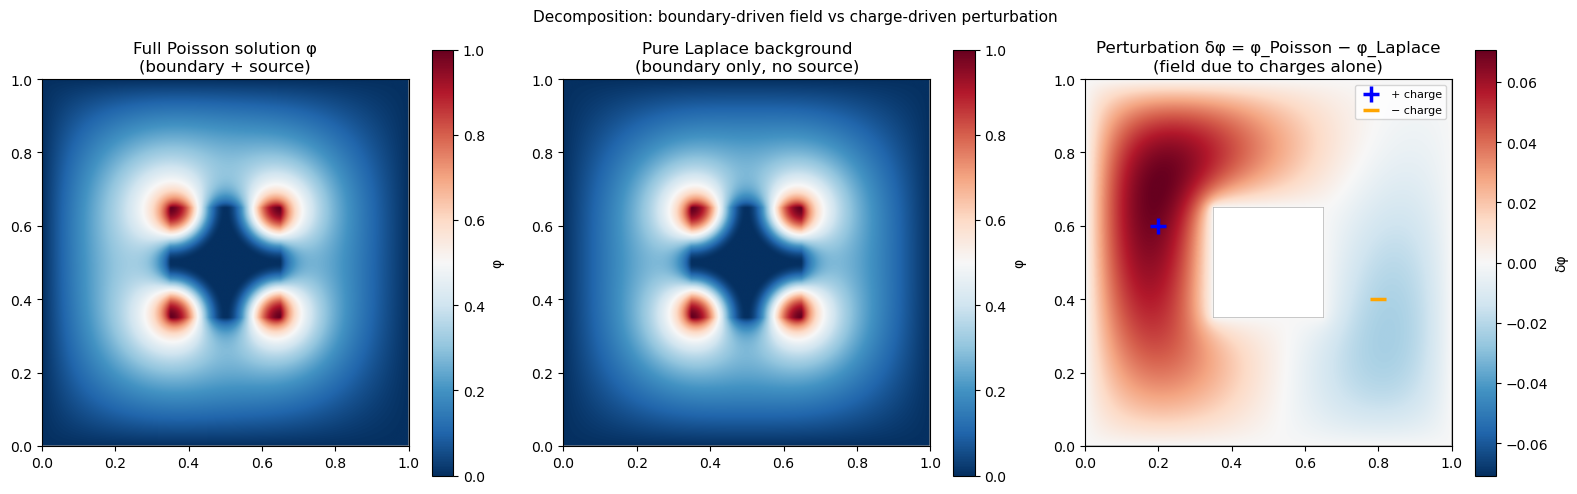

In [5]:

b_laplace = np.zeros(n_total)
b_laplace[flat_obstacle] = nearest_face_bc(obs_xy)
b_laplace[flat_exterior] = 0.0

print("Solving pure Laplace (sparse direct)...")
phi_laplace_flat = spsolve(A, b_laplace)
phi_laplace      = phi_laplace_flat.reshape(N, N)
print("Done.")

delta_phi = phi - phi_laplace
delta_phi[~mask_domain & ~mask_obstacle] = np.nan
delta_phi[mask_obstacle] = np.nan

print(f"\nPerturbation field stats:")
print(f"  max δφ: {np.nanmax(delta_phi):.6f}  (near + charge, should be positive)")
print(f"  min δφ: {np.nanmin(delta_phi):.6f}  (near - charge, should be negative)")
print(f"  Difference: {np.nanmax(delta_phi) - np.nanmin(delta_phi):.6f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
phi_plot = phi.copy().astype(float)
phi_plot[~mask_domain & ~mask_obstacle] = np.nan
cf = ax.imshow(phi_plot.T, origin='lower', extent=[0, 1, 0, 1],
               cmap='RdBu_r', vmin=0, vmax=1)
plt.colorbar(cf, ax=ax, label='φ')
ax.set_title('Full Poisson solution φ\n(boundary + source)')
ax.set_aspect('equal')

ax = axes[1]
lap_plot = phi_laplace.copy().astype(float)
lap_plot[~mask_domain & ~mask_obstacle] = np.nan
cf2 = ax.imshow(lap_plot.T, origin='lower', extent=[0, 1, 0, 1],
                cmap='RdBu_r', vmin=0, vmax=1)
plt.colorbar(cf2, ax=ax, label='φ')
ax.set_title('Pure Laplace background\n(boundary only, no source)')
ax.set_aspect('equal')

ax = axes[2]
vmax_d = np.nanmax(np.abs(delta_phi))
norm_d = TwoSlopeNorm(vmin=-vmax_d, vcenter=0, vmax=vmax_d)
cf3 = ax.imshow(delta_phi.T, origin='lower', extent=[0, 1, 0, 1],
                cmap='RdBu_r', norm=norm_d)
plt.colorbar(cf3, ax=ax, label='δφ')
ax.scatter(*POS_CENTER, color='blue',   s=120, zorder=6,
           marker='+', linewidths=2.5, label='+ charge')
ax.scatter(*NEG_CENTER, color='orange', s=120, zorder=6,
           marker='_', linewidths=2.5, label='− charge')
ax.set_title('Perturbation δφ = φ_Poisson − φ_Laplace\n(field due to charges alone)')
ax.legend(fontsize=8)
ax.set_aspect('equal')

plt.suptitle('Decomposition: boundary-driven field vs charge-driven perturbation',
             fontsize=11)
plt.tight_layout()
plt.show()

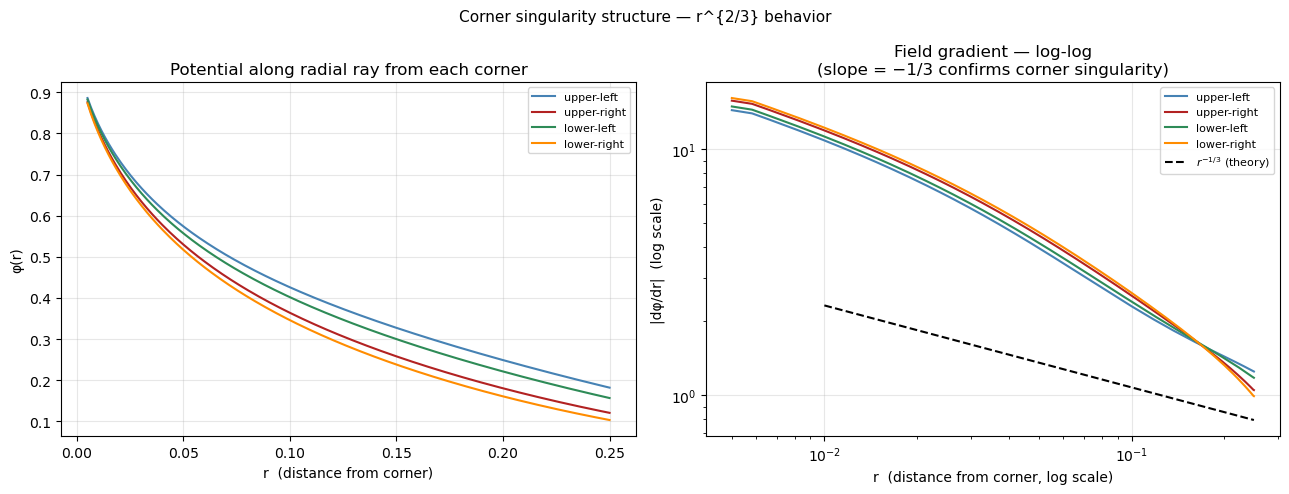

In [6]:

corners = {
    'upper-left':  (0.35, 0.65),
    'upper-right': (0.65, 0.65),
    'lower-left':  (0.35, 0.35),
    'lower-right': (0.65, 0.35),
}

directions = {
    'upper-left':  (-1,  1),
    'upper-right': ( 1,  1),
    'lower-left':  (-1, -1),
    'lower-right': ( 1, -1),
}

r_vals = np.linspace(0.005, 0.25, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax_phi  = axes[0]  
ax_grad = axes[1]   

colors = ['steelblue', 'firebrick', 'seagreen', 'darkorange']

for (name, corner), (_, direction), color in zip(
        corners.items(), directions.items(), colors):

    cx, cy = corner
    dx, dy = direction
    norm   = np.sqrt(dx**2 + dy**2)
    dx, dy = dx / norm, dy / norm   

    xs_ray = cx + r_vals * dx
    ys_ray = cy + r_vals * dy
    pts_ray = np.stack([xs_ray, ys_ray], axis=1)

    inside = np.array([domain.contains(Point(p)) for p in pts_ray])
    r_in   = r_vals[inside]
    pts_in = pts_ray[inside]

    if len(r_in) < 10:
        continue

    phi_ray = phi_reference(pts_in)


    dphi_dr = np.gradient(phi_ray, r_in)


    ax_phi.plot(r_in, phi_ray, color=color, lw=1.5, label=name)

    ax_grad.loglog(r_in, np.abs(dphi_dr), color=color, lw=1.5, label=name)


r_theory = np.linspace(0.01, 0.25, 100)

ax_grad.loglog(r_theory, 0.5 * r_theory**(-1/3), 'k--',
               lw=1.5, label=r'$r^{-1/3}$ (theory)')

ax_phi.set_xlabel('r  (distance from corner)')
ax_phi.set_ylabel('φ(r)')
ax_phi.set_title('Potential along radial ray from each corner')
ax_phi.legend(fontsize=8)
ax_phi.grid(True, alpha=0.3)

ax_grad.set_xlabel('r  (distance from corner, log scale)')
ax_grad.set_ylabel('|dφ/dr|  (log scale)')
ax_grad.set_title('Field gradient — log-log\n(slope = −1/3 confirms corner singularity)')
ax_grad.legend(fontsize=8)
ax_grad.grid(True, alpha=0.3)

plt.suptitle('Corner singularity structure — r^{2/3} behavior', fontsize=11)
plt.tight_layout()
plt.show()

5) Building the training datasets. \
General idea is we want to avoid random sampling, as both the corners of the interior square, charges and boundary conditions are way more important than the empty, smooth potential regions. \
Have 3 ways to sample: \ 

**Collocation points** `(X_colloc)` are interior points where the PDE residual ∇²φ = −ρ is enforced. No labels are needed — the physics constraint is the supervision signal. Sampling is intentionally non-uniform: points are concentrated near the obstacle boundary (where corner singularities produce the steepest gradients) and near the charge centers (where the source term is largest).

**Boundary points** `(X_bc, Y_bc)` carry Dirichlet labels: φ = 0 on the outer wall and φ = 1 on the obstacle surface. These anchor the solution to the correct boundary conditions.

**Supervised data points** `(X_data, Y_data)` are interior points labeled with the FD reference solution φ_ref(x,y) queried through the interpolator. These provide direct supervision on the field values and are especially important early in training before the PDE loss has converged.

Each point is represented as a six-dimensional feature vector:

$$(x,\ y,\ \log s,\ c_x,\ c_y,\ d(x,y))$$

where $s$ is the zoom scale, $(c_x, c_y)$ is the window center, and $d(x,y)$ is the signed distance to the nearest boundary. Using $\log s$ rather than $s$ directly respects the logarithmic nature of scale — equal multiplicative changes in zoom level produce equal additive changes in the feature.

All three pools are sampled at multiple scales $s \in \{1.0, 0.5, 0.25, 0.1\}$ with window centers concentrated on the physically interesting regions (obstacle corners, charge centers). The finest scale $s = 0.05$ is reserved entirely for the test set to evaluate generalization to unseen zoom levels.

The dataset is split 90/10 into train and validation. The held-out $s = 0.05$ scale forms a separate test set that the network never sees during training.


In [7]:

dist_inside  = distance_transform_edt(mask_domain)  * h
dist_outside = distance_transform_edt(~mask_domain) * h
sdf_grid     = dist_inside - dist_outside

sdf_interpolator = RegularGridInterpolator(
    (xs, ys), sdf_grid,
    method='linear', bounds_error=False, fill_value=0.0
)

print("SDF sanity check:")
test_pts = np.array([[0.25, 0.50], [0.50, 0.50], [0.00, 0.50]])
for pt, label in zip(test_pts, ['interior', 'obstacle', 'outer wall']):
    print(f"  {label} {tuple(pt)}: sdf = {sdf_interpolator([pt])[0]:.4f}")

def make_features(xy, scale, center):
    """(N, 6): [x, y, log_s, cx, cy, sdf]"""
    n        = len(xy)
    sdf_vals = sdf_interpolator(xy)
    log_s    = np.full(n, np.log(scale))
    cx       = np.full(n, center[0])
    cy       = np.full(n, center[1])
    return np.column_stack([xy, log_s, cx, cy, sdf_vals])

def sample_domain_uniform(n):
    pts = []
    while len(pts) < n:
        candidates = np.random.uniform(0, 1, (n * 4, 2))
        inside = contains(domain, candidates[:, 0], candidates[:, 1])
        pts.extend(candidates[inside].tolist())
    return np.array(pts[:n])

def sample_near_obstacle_boundary(n, radius=0.06):
    pts = []
    x0, x1 = 0.35 - radius, 0.65 + radius
    y0, y1 = 0.35 - radius, 0.65 + radius
    while len(pts) < n:
        candidates = np.random.uniform([x0, y0], [x1, y1], (n * 6, 2))
        in_domain     = contains(domain, candidates[:, 0], candidates[:, 1])
        sdf_vals      = sdf_interpolator(candidates)
        near_boundary = (sdf_vals > 0) & (sdf_vals < radius)
        valid = in_domain & near_boundary
        pts.extend(candidates[valid].tolist())
    return np.array(pts[:n])

def sample_near_charges(n, radius=0.12):
    pts = []
    centers = [POS_CENTER, NEG_CENTER]
    while len(pts) < n:
        for cx, cy in centers:
            candidates = np.clip(
                np.random.uniform([cx-radius, cy-radius],
                                  [cx+radius, cy+radius], (n*3, 2)), 0, 1)
            in_domain = contains(domain, candidates[:, 0], candidates[:, 1])
            pts.extend(candidates[in_domain].tolist())
    return np.array(pts[:n])

def sample_window(polygon, window_center, scale, n):
    cx, cy = window_center
    half   = scale / 2.0
    window = sbox(cx-half, cy-half, cx+half, cy+half)
    region = domain.intersection(window)
    if region.is_empty or region.area < 1e-8:
        return None
    minx, miny, maxx, maxy = region.bounds
    pts = []
    while len(pts) < n:
        candidates = np.random.uniform([minx, miny], [maxx, maxy], (n*6, 2))
        from shapely.vectorized import contains as vc
        inside = vc(region, candidates[:, 0], candidates[:, 1])
        pts.extend(candidates[inside].tolist())
    return np.array(pts[:n])

def sample_boundary_points(n_outer, n_obstacle):

    outer_boundary = domain.exterior
    total_len      = outer_boundary.length
    ts             = np.random.uniform(0, total_len, n_outer)
    outer_pts      = np.array([list(outer_boundary.interpolate(t).coords[0]) for t in ts])
    outer_vals     = np.zeros(n_outer)

    obs_boundary = list(domain.interiors)[0]
    total_len    = obs_boundary.length
    ts           = np.random.uniform(0, total_len, n_obstacle)
    obs_pts      = np.array([list(obs_boundary.interpolate(t).coords[0]) for t in ts])
    obs_vals     = nearest_face_bc(obs_pts)   # cos² BC

    xy   = np.vstack([outer_pts, obs_pts])
    vals = np.concatenate([outer_vals, obs_vals])
    return xy, vals


SCALES_TRAIN = [1.0, 0.5, 0.25, 0.1]
SCALES_TEST  = [0.05]

SCALE_WINDOWS = {
    1.00: [(0.5,  0.5)],
    0.50: [(0.5,  0.5),  (0.35, 0.65), (0.65, 0.35)],
    0.25: [(0.5,  0.5),  (0.35, 0.65), (0.65, 0.35),
           (0.20, 0.60), (0.80, 0.40)],   
    0.10: [(0.35, 0.65), (0.65, 0.35),
           (0.20, 0.60), (0.80, 0.40)],   
    0.05: [(0.35, 0.65), (0.65, 0.35)],
}

# Added two more unseen scale windows to be held out for final test
SCALE_WINDOWS[0.02] = [(0.35, 0.65), (0.65, 0.35)]
SCALE_WINDOWS[0.01] = [(0.35, 0.65), (0.65, 0.35)]

N_COLLOC_GLOBAL = 8000
N_COLLOC_CORNER = 2000
N_COLLOC_CHARGE = 1000
N_COLLOC_WINDOW = 500
N_BC_OUTER      = 1000
N_BC_OBSTACLE   = 1000
N_BC_WINDOW     = 200
N_DATA_GLOBAL   = 5000
N_DATA_CORNER   = 1500
N_DATA_WINDOW   = 300


print("Building collocation pool...")
colloc_parts = []
xy_uniform = sample_domain_uniform(N_COLLOC_GLOBAL)
xy_corner  = sample_near_obstacle_boundary(N_COLLOC_CORNER)
xy_charge  = sample_near_charges(N_COLLOC_CHARGE)
colloc_parts.append(make_features(xy_uniform, 1.0, (0.5, 0.5)))
colloc_parts.append(make_features(xy_corner,  1.0, (0.5, 0.5)))
colloc_parts.append(make_features(xy_charge,  1.0, (0.5, 0.5)))
for scale in SCALES_TRAIN[1:]:
    for center in SCALE_WINDOWS[scale]:
        xy_w = sample_window(domain, center, scale, N_COLLOC_WINDOW)
        if xy_w is not None:
            colloc_parts.append(make_features(xy_w, scale, center))
X_colloc = np.vstack(colloc_parts)
print(f"  Collocation pool: {len(X_colloc):,} points  shape {X_colloc.shape}")


print("Building boundary pool...")
bc_parts_x, bc_parts_y = [], []
xy_bc_global, y_bc_global = sample_boundary_points(N_BC_OUTER, N_BC_OBSTACLE)
bc_parts_x.append(make_features(xy_bc_global, 1.0, (0.5, 0.5)))
bc_parts_y.append(y_bc_global)

for scale in SCALES_TRAIN[1:]:
    for center in SCALE_WINDOWS[scale]:
        half   = scale / 2
        cx, cy = center
        window = sbox(cx-half, cy-half, cx+half, cy+half)
        obs_boundary = list(domain.interiors)[0]
        ts = np.random.uniform(0, obs_boundary.length, N_BC_WINDOW * 10)
        pts_on_obs = np.array([list(obs_boundary.interpolate(t).coords[0]) for t in ts])
        in_window  = np.array([window.contains(Point(p)) for p in pts_on_obs])
        pts_in     = pts_on_obs[in_window]
        if len(pts_in) > N_BC_WINDOW:
            pts_in = pts_in[np.random.choice(len(pts_in), N_BC_WINDOW, replace=False)]
        if len(pts_in) > 0:
            bc_parts_x.append(make_features(pts_in, scale, center))
            bc_parts_y.append(nearest_face_bc(pts_in))   # cos² BC, not ones

X_bc = np.vstack(bc_parts_x)
Y_bc = np.concatenate(bc_parts_y)
print(f"  Boundary pool: {len(X_bc):,} points  shape {X_bc.shape}")

print("Building supervised data pool...")
data_parts_x, data_parts_y = [], []
xy_data_corner = sample_near_obstacle_boundary(N_DATA_CORNER)
xy_data_charge = sample_near_charges(N_DATA_CORNER // 2)
xy_data_global = sample_domain_uniform(N_DATA_GLOBAL)
for xy, scale, center in [
    (xy_data_global, 1.0, (0.5, 0.5)),
    (xy_data_corner, 1.0, (0.5, 0.5)),
    (xy_data_charge, 1.0, (0.5, 0.5)),
]:
    data_parts_x.append(make_features(xy, scale, center))
    data_parts_y.append(phi_reference(xy))
for scale in SCALES_TRAIN[1:]:
    for center in SCALE_WINDOWS[scale]:
        xy_w = sample_window(domain, center, scale, N_DATA_WINDOW)
        if xy_w is not None:
            data_parts_x.append(make_features(xy_w, scale, center))
            data_parts_y.append(phi_reference(xy_w))
X_data = np.vstack(data_parts_x)
Y_data = np.concatenate(data_parts_y)
print(f"  Data pool: {len(X_data):,} points  shape {X_data.shape}")

idx_c = np.arange(len(X_colloc))
idx_c_train, idx_c_val = train_test_split(idx_c, test_size=0.1, random_state=42)
X_colloc_train = X_colloc[idx_c_train]
X_colloc_val   = X_colloc[idx_c_val]

idx_b = np.arange(len(X_bc))
idx_b_train, idx_b_val = train_test_split(idx_b, test_size=0.1, random_state=42)
X_bc_train, Y_bc_train = X_bc[idx_b_train], Y_bc[idx_b_train]
X_bc_val,   Y_bc_val   = X_bc[idx_b_val],   Y_bc[idx_b_val]

idx_d = np.arange(len(X_data))
idx_d_train, idx_d_val = train_test_split(idx_d, test_size=0.1, random_state=42)
X_data_train, Y_data_train = X_data[idx_d_train], Y_data[idx_d_train]
X_data_val,   Y_data_val   = X_data[idx_d_val],   Y_data[idx_d_val]

print("\nBuilding test set at unseen scale s=0.05...")
test_parts_x, test_parts_y = [], []
for center in SCALE_WINDOWS[0.05]:
    xy_test = sample_window(domain, center, 0.05, 1000)
    if xy_test is not None:
        test_parts_x.append(make_features(xy_test, 0.05, center))
        test_parts_y.append(phi_reference(xy_test))
X_test = np.vstack(test_parts_x)
Y_test = np.concatenate(test_parts_y)
print(f"  Test set: {len(X_test):,} points")

print(f"\nCollocation  train: {len(X_colloc_train):,}   val: {len(X_colloc_val):,}")
print(f"Boundary     train: {len(X_bc_train):,}   val: {len(X_bc_val):,}")
print(f"Data         train: {len(X_data_train):,}   val: {len(X_data_val):,}")
print(f"Test (s=0.05):      {len(X_test):,}")
print(f"Input dimension: {X_colloc_train.shape[1]}  (expected 6)")
print(f"\nBC value range: [{Y_bc_train.min():.4f}, {Y_bc_train.max():.4f}]  (expected [0, 1])")
print(f"Data label range: [{Y_data_train.min():.4f}, {Y_data_train.max():.4f}]")

SDF sanity check:
  interior (np.float64(0.25), np.float64(0.5)): sdf = 0.1000
  obstacle (np.float64(0.5), np.float64(0.5)): sdf = -0.1505
  outer wall (np.float64(0.0), np.float64(0.5)): sdf = -0.0010
Building collocation pool...
  Collocation pool: 16,500 points  shape (16500, 6)
Building boundary pool...


/var/folders/__/68q69_j51cj16zb24xlwg1kw0000gn/T/ipykernel_76956/1364219630.py:28: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  inside = contains(domain, candidates[:, 0], candidates[:, 1])
/var/folders/__/68q69_j51cj16zb24xlwg1kw0000gn/T/ipykernel_76956/1364219630.py:38: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  in_domain     = contains(domain, candidates[:, 0], candidates[:, 1])
/var/folders/__/68q69_j51cj16zb24xlwg1kw0000gn/T/ipykernel_76956/1364219630.py:53: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  in_domain = contains(domain, candidates[:, 0], candidates[:, 1])
/va

  Boundary pool: 3,309 points  shape (3309, 6)
Building supervised data pool...
  Data pool: 10,550 points  shape (10550, 6)

Building test set at unseen scale s=0.05...
  Test set: 2,000 points

Collocation  train: 14,850   val: 1,650
Boundary     train: 2,978   val: 331
Data         train: 9,495   val: 1,055
Test (s=0.05):      2,000
Input dimension: 6  (expected 6)

BC value range: [0.0000, 1.0000]  (expected [0, 1])
Data label range: [0.0000, 0.9848]


Show explicitly where our training data is sampled from

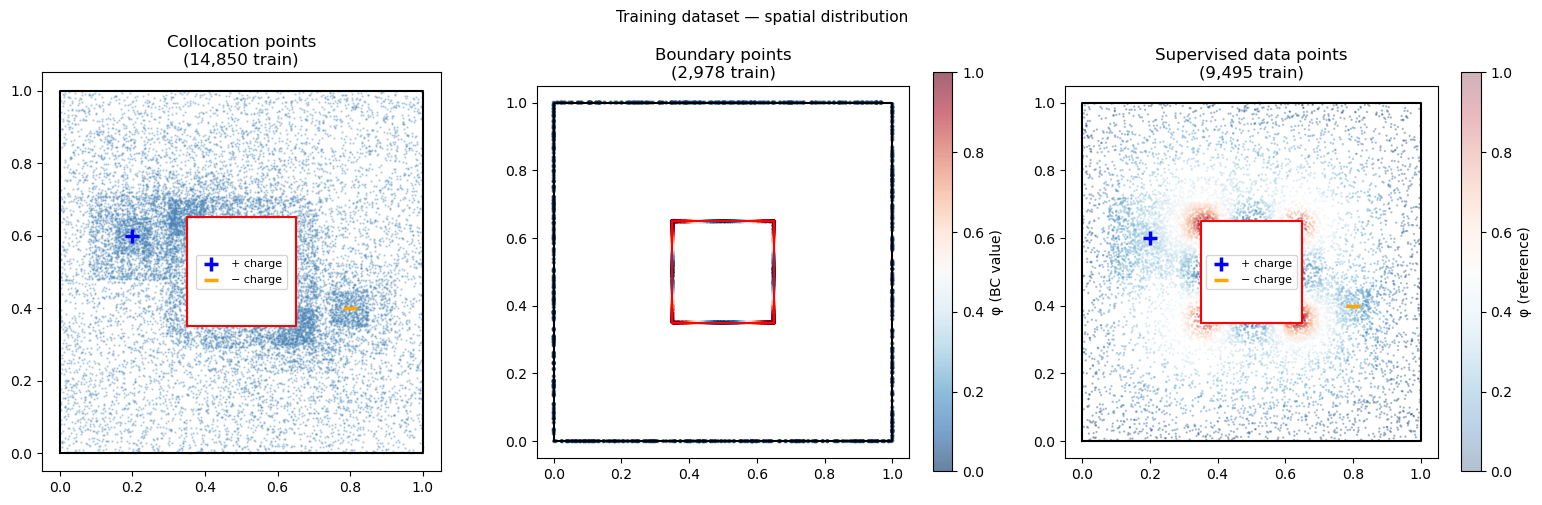

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.scatter(X_colloc_train[:, 0], X_colloc_train[:, 1],
           s=0.5, alpha=0.3, c='steelblue')
ax.plot(*np.array(outer    + [outer[0]]).T, 'k-', lw=1.5)
ax.plot(*np.array(obstacle + [obstacle[0]]).T, 'r-', lw=1.5)
ax.scatter(*POS_CENTER, color='blue',   s=100, zorder=6, marker='+',
           linewidths=2.5, label='+ charge')
ax.scatter(*NEG_CENTER, color='orange', s=100, zorder=6, marker='_',
           linewidths=2.5, label='− charge')
ax.set_aspect('equal')
ax.legend(fontsize=8)
ax.set_title(f'Collocation points\n({len(X_colloc_train):,} train)')

ax = axes[1]
sc = ax.scatter(X_bc_train[:, 0], X_bc_train[:, 1],
                s=4, alpha=0.6, c=Y_bc_train, cmap='RdBu_r',
                vmin=0, vmax=1)
plt.colorbar(sc, ax=ax, label='φ (BC value)')
ax.plot(*np.array(outer    + [outer[0]]).T, 'k-', lw=1.5)
ax.plot(*np.array(obstacle + [obstacle[0]]).T, 'r-', lw=1.5)
ax.set_aspect('equal')
ax.set_title(f'Boundary points\n({len(X_bc_train):,} train)')

ax = axes[2]
sc2 = ax.scatter(X_data_train[:, 0], X_data_train[:, 1],
                 s=0.5, alpha=0.3, c=Y_data_train, cmap='RdBu_r',
                 vmin=0, vmax=1)
plt.colorbar(sc2, ax=ax, label='φ (reference)')
ax.plot(*np.array(outer    + [outer[0]]).T, 'k-', lw=1.5)
ax.plot(*np.array(obstacle + [obstacle[0]]).T, 'r-', lw=1.5)
ax.scatter(*POS_CENTER, color='blue',   s=100, zorder=6, marker='+',
           linewidths=2.5, label='+ charge')
ax.scatter(*NEG_CENTER, color='orange', s=100, zorder=6, marker='_',
           linewidths=2.5, label='− charge')
ax.set_aspect('equal')
ax.legend(fontsize=8)
ax.set_title(f'Supervised data points\n({len(X_data_train):,} train)')

plt.suptitle('Training dataset — spatial distribution', fontsize=11)
plt.tight_layout()
plt.show()

In [9]:

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cpu')
torch.set_default_dtype(torch.float32)
print(f'Device: {device}')

N_FOURIER    = 32
SIGMA_COARSE = 1.0
SIGMA_FINE   = 3.0
HIDDEN_DIM   = 256
N_LAYERS     = 6

class FourierFeaturePINN(nn.Module):
    def __init__(self, n_fourier=N_FOURIER, sigma_coarse=SIGMA_COARSE,
                 sigma_fine=SIGMA_FINE, hidden_dim=HIDDEN_DIM, n_layers=N_LAYERS):
        super().__init__()

        B_coarse = torch.randn(2, n_fourier) * sigma_coarse
        B_fine   = torch.randn(2, n_fourier) * sigma_fine
        self.register_buffer('B_coarse', B_coarse)
        self.register_buffer('B_fine',   B_fine)

        context_dim = 4   # log_s, cx, cy, sdf
        input_dim   = 4 * n_fourier + context_dim   # 132

        layers = [nn.Linear(input_dim, hidden_dim), nn.Tanh()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, 1)]
        self.net = nn.Sequential(*layers)

        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def encode(self, z):
        xy      = z[:, :2]
        context = z[:, 2:]
        proj_c  = xy @ self.B_coarse
        proj_f  = xy @ self.B_fine
        ff_c = torch.cat([torch.sin(2*np.pi*proj_c),
                          torch.cos(2*np.pi*proj_c)], dim=1)
        ff_f = torch.cat([torch.sin(2*np.pi*proj_f),
                          torch.cos(2*np.pi*proj_f)], dim=1)
        return torch.cat([ff_c, ff_f, context], dim=1)

    def forward(self, z):
        return self.net(self.encode(z))

    def laplacian(self, z):
        z    = z.clone().detach().requires_grad_(True)
        phi  = self.forward(z)
        grad = torch.autograd.grad(phi.sum(), z, create_graph=True)[0]
        phi_x  = grad[:, 0:1]
        phi_y  = grad[:, 1:2]
        phi_xx = torch.autograd.grad(phi_x.sum(), z, create_graph=True)[0][:, 0:1]
        phi_yy = torch.autograd.grad(phi_y.sum(), z, create_graph=True)[0][:, 1:2]
        return phi_xx + phi_yy

model = FourierFeaturePINN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: {n_params:,} trainable parameters')

dummy = torch.randn(8, 6).to(device)
with torch.no_grad():
    out = model(dummy)
print(f'Forward pass: {dummy.shape} → {out.shape}')
lap = model.laplacian(dummy)
print(f'Laplacian:    {dummy.shape} → {lap.shape}')
print('Architecture OK.')
model = FourierFeaturePINN().to(device)

Device: cpu
Model: 363,265 trainable parameters
Forward pass: torch.Size([8, 6]) → torch.Size([8, 1])
Laplacian:    torch.Size([8, 6]) → torch.Size([8, 1])
Architecture OK.


In [10]:

W_PDE   = 1.0
W_BC    = 600.0   # cos² BC is harder than uniform — needs stronger enforcement
W_DATA  = 50.0
W_SCALE = 0.0

def to_tensor(arr, grad=False):
    t = torch.tensor(arr, dtype=torch.float32, device=device)
    if grad:
        t = t.requires_grad_(True)
    return t

def loss_pde(model, z_colloc, xy_colloc):
    lap  = model.laplacian(z_colloc)
    x_np = xy_colloc[:, 0].detach().cpu().numpy()
    y_np = xy_colloc[:, 1].detach().cpu().numpy()
    rho  = to_tensor(source_term(x_np, y_np).reshape(-1, 1))
    residual = lap + rho
    return (residual ** 2).mean()

def loss_bc(model, z_bc, y_bc):
    phi_pred = model(z_bc).squeeze()
    return ((phi_pred - y_bc) ** 2).mean()

def loss_data(model, z_data, y_data):
    phi_pred = model(z_data).squeeze()
    return ((phi_pred - y_data) ** 2).mean()

def loss_scale_consistency(model, xy_shared, n_pairs=300):
    idx = np.random.choice(len(xy_shared), min(n_pairs, len(xy_shared)), replace=False)
    xy  = xy_shared[idx]
    z_global = to_tensor(make_features(xy, scale=1.0, center=(0.5, 0.5)))
    phi_global = model(z_global)
    total = torch.tensor(0.0, device=device)
    for scale in [0.5, 0.25]:
        z_zoom   = to_tensor(make_features(xy, scale=scale, center=(0.5, 0.5)))
        phi_zoom = model(z_zoom)
        total   += ((phi_global - phi_zoom) ** 2).mean()
    return total / 2.0


Z_colloc_full  = to_tensor(X_colloc_train)
XY_colloc_full = to_tensor(X_colloc_train[:, :2])
Z_bc           = to_tensor(X_bc_train)
Y_bc_t         = to_tensor(Y_bc_train)
Z_data         = to_tensor(X_data_train)
Y_data_t       = to_tensor(Y_data_train)
Z_bc_val_t     = to_tensor(X_bc_val)
Y_bc_val_t     = to_tensor(Y_bc_val)
Z_data_val_t   = to_tensor(X_data_val)
Y_data_val_t   = to_tensor(Y_data_val)
xy_scale_pool  = X_colloc_train[:, :2]

print(f'Loss weights:  PDE={W_PDE}  BC={W_BC}  Data={W_DATA}  Scale={W_SCALE}')
print(f'Collocation: {Z_colloc_full.shape}')
print(f'Boundary:    {Z_bc.shape}')
print(f'Data:        {Z_data.shape}')
with torch.no_grad():
    print(f'BC loss (untrained):   {loss_bc(model, Z_bc, Y_bc_t).item():.4f}')
    print(f'Data loss (untrained): {loss_data(model, Z_data, Y_data_t).item():.4f}')

Loss weights:  PDE=1.0  BC=600.0  Data=50.0  Scale=0.0
Collocation: torch.Size([14850, 6])
Boundary:    torch.Size([2978, 6])
Data:        torch.Size([9495, 6])
BC loss (untrained):   0.4741
Data loss (untrained): 0.3138


Phase 1: Adam  (2000 steps, batch=1024)
  Step        Loss         PDE          BC        Data       Scale         Val    ramp
-------------------------------------------------------------------------------------
     1  3.0017e+02  0.0000e+00  4.7413e-01  3.1383e-01  0.0000e+00  1.2267e+02   0.000
   250  2.5839e-01  0.0000e+00  3.3364e-04  1.1642e-03  0.0000e+00  4.2299e-01   0.000
   500  8.9654e-02  0.0000e+00  9.9410e-05  6.0016e-04  0.0000e+00  9.5794e-02   0.000
   750  2.0249e-01  0.0000e+00  2.9607e-04  4.9690e-04  0.0000e+00  1.1882e-01   0.000
  1000  9.2940e-02  0.0000e+00  1.3183e-04  2.7681e-04  0.0000e+00  3.5650e-02   0.000
  1250  8.4288e-02  0.0000e+00  1.1888e-04  2.5922e-04  0.0000e+00  7.0093e-02   0.000
  [step 1500] LR → 0.001  |  PDE ramping in...
  1500  5.5697e-02  0.0000e+00  7.2219e-05  2.4732e-04  0.0000e+00  1.4372e-01   0.000
  1750  9.3061e+00  1.7410e+02  3.2839e-03  1.6305e-03  3.5336e-04  2.1481e+00   0.042
  2000  1.1687e+01  8.9227e+01  6.7471e-03  

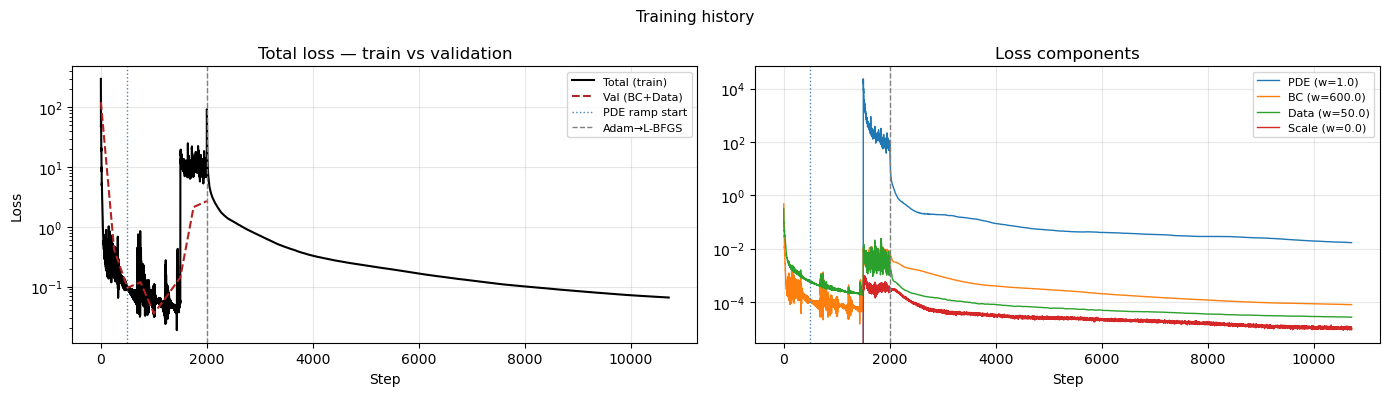

Checkpoint saved.


In [11]:
BATCH_SIZE = 1024
N_ADAM     = 2000
N_LBFGS    = 7000
LR_ADAM    = 1e-3


history = {
    'loss': [], 'l_pde': [], 'l_bc': [],
    'l_data': [], 'l_scale': [],
    'val_loss': [], 'val_bc': [], 'val_data': []
}

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print(f'Phase 1: Adam  ({N_ADAM} steps, batch={BATCH_SIZE})')
print(f'{"Step":>6}  {"Loss":>10}  {"PDE":>10}  {"BC":>10}  '
      f'{"Data":>10}  {"Scale":>10}  {"Val":>10}  {"ramp":>6}')
print('-' * 85)

for step in range(1, N_ADAM + 1):
    model.train()

    if step == 1500:
        for pg in optimizer.param_groups:
            pg['lr'] = LR_ADAM
        print(f'  [step {step}] LR → {LR_ADAM}  |  PDE ramping in...')

    idx      = np.random.choice(len(Z_colloc_full), BATCH_SIZE, replace=False)
    z_batch  = Z_colloc_full[idx]
    xy_batch = XY_colloc_full[idx]

    if step > N_ADAM // 2:
        n_zoom   = BATCH_SIZE // 4
        idx_z    = np.random.choice(len(Z_colloc_full), n_zoom, replace=False)
        z_batch  = torch.cat([z_batch,  Z_colloc_full[idx_z]], dim=0)
        xy_batch = torch.cat([xy_batch, XY_colloc_full[idx_z]], dim=0)

    if step <= 1500:
        l_bc     = loss_bc(model, Z_bc, Y_bc_t)
        l_data   = loss_data(model, Z_data, Y_data_t)
        loss     = W_BC * l_bc + W_DATA * l_data
        l_pde    = torch.tensor(0.0, device=device)
        l_scale  = torch.tensor(0.0, device=device)
        pde_ramp = 0.0
    else:
        pde_ramp = min(1.0, (step - 1500) / 6000.0)
        l_pde    = loss_pde(model, z_batch, xy_batch)
        l_bc     = loss_bc(model, Z_bc, Y_bc_t)
        l_data   = loss_data(model, Z_data, Y_data_t)
        l_scale  = loss_scale_consistency(model, xy_scale_pool)
        loss     = (pde_ramp * W_PDE * l_pde +
                    W_BC    * l_bc            +
                    W_DATA  * l_data          +
                    W_SCALE * l_scale)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()   

    history['loss'].append(loss.item())
    history['l_pde'].append(l_pde.item())
    history['l_bc'].append(l_bc.item())
    history['l_data'].append(l_data.item())
    history['l_scale'].append(l_scale.item())

    if step % 250 == 0 or step == 1:
        model.eval()
        with torch.no_grad():
            val_bc   = loss_bc(model, Z_bc_val_t, Y_bc_val_t).item()
            val_data = loss_data(model, Z_data_val_t, Y_data_val_t).item()
            val_loss = W_BC * val_bc + W_DATA * val_data
        history['val_loss'].append(val_loss)
        history['val_bc'].append(val_bc)
        history['val_data'].append(val_data)
        print(f'{step:>6}  {loss.item():>10.4e}  {l_pde.item():>10.4e}  '
              f'{l_bc.item():>10.4e}  {l_data.item():>10.4e}  '
              f'{l_scale.item():>10.4e}  {val_loss:>10.4e}  '
              f'{pde_ramp:>6.3f}')
        model.train()

print('\nAdam phase complete.')

print(f'\nPhase 2: L-BFGS  ({N_LBFGS} evaluations)')
optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(), lr=0.1, max_iter=20,
    history_size=50, line_search_fn='strong_wolfe'
)
lbfgs_count = [0]

def closure():
    optimizer_lbfgs.zero_grad()
    l_pde   = loss_pde(model, Z_colloc_full, XY_colloc_full)
    l_bc    = loss_bc(model, Z_bc, Y_bc_t)
    l_data  = loss_data(model, Z_data, Y_data_t)
    l_scale = loss_scale_consistency(model, xy_scale_pool)
    loss    = W_PDE*l_pde + W_BC*l_bc + W_DATA*l_data + W_SCALE*l_scale
    loss.backward()
    lbfgs_count[0] += 1
    history['loss'].append(loss.item())
    history['l_pde'].append(l_pde.item())
    history['l_bc'].append(l_bc.item())
    history['l_data'].append(l_data.item())
    history['l_scale'].append(l_scale.item())
    if lbfgs_count[0] % 25 == 0:
        print(f'  L-BFGS eval {lbfgs_count[0]:4d} | Loss {loss.item():.4e} | '
              f'BC {l_bc.item():.4e} | Data {l_data.item():.4e}')
    return loss

for _ in range(N_LBFGS // 20):
    optimizer_lbfgs.step(closure)

print('L-BFGS phase complete.')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
ax.semilogy(history['loss'], color='black', lw=1.5, label='Total (train)')
val_steps = [1] + list(range(250, N_ADAM+1, 250))
val_steps = val_steps[:len(history['val_loss'])]
ax.semilogy(val_steps, history['val_loss'], color='firebrick',
            lw=1.5, ls='--', label='Val (BC+Data)')
ax.axvline(500,    color='steelblue', ls=':', lw=1, label='PDE ramp start')
ax.axvline(N_ADAM, color='gray',      ls='--', lw=1, label='Adam→L-BFGS')
ax.set_xlabel('Step'); ax.set_ylabel('Loss')
ax.set_title('Total loss — train vs validation')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogy(history['l_pde'],   lw=1, label=f'PDE (w={W_PDE})')
ax.semilogy(history['l_bc'],    lw=1, label=f'BC (w={W_BC})')
ax.semilogy(history['l_data'],  lw=1, label=f'Data (w={W_DATA})')
ax.semilogy(history['l_scale'], lw=1, label=f'Scale (w={W_SCALE})')
ax.axvline(500,    color='steelblue', ls=':', lw=1)
ax.axvline(N_ADAM, color='gray',      ls='--', lw=1)
ax.set_xlabel('Step'); ax.set_title('Loss components')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Training history', fontsize=11)
plt.tight_layout()
plt.savefig('ModelOutput/training_history.png', dpi=150)
plt.show()

torch.save({
    'model_state': model.state_dict(),
    'history':     history,
    'config': {'N_FOURIER': N_FOURIER, 'SIGMA_COARSE': SIGMA_COARSE,
               'SIGMA_FINE': SIGMA_FINE, 'HIDDEN_DIM': HIDDEN_DIM,
               'N_LAYERS': N_LAYERS, 'W_BC': W_BC, 'W_DATA': W_DATA}
}, 'ModelOutput/pinn_checkpoint.pt')
print('Checkpoint saved.')

Evaluating global prediction...
  Global relative L2 error: 0.0194


/var/folders/__/68q69_j51cj16zb24xlwg1kw0000gn/T/ipykernel_76956/1494731803.py:19: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  inside = contains(domain, pts[:, 0], pts[:, 1])


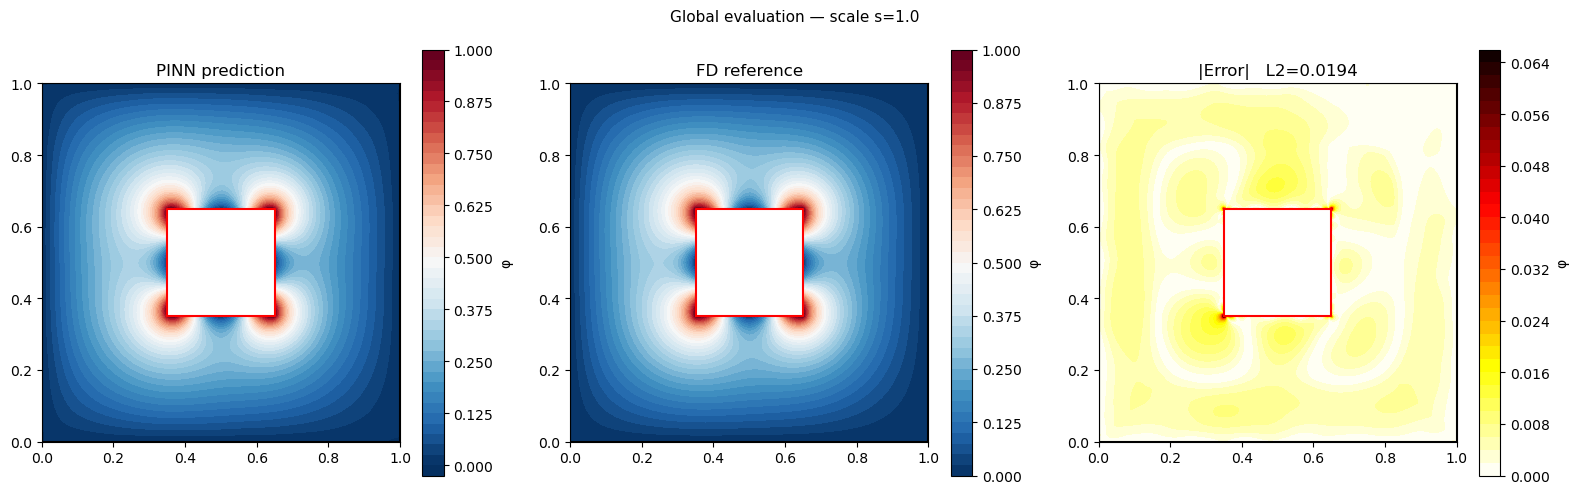

Evaluating zoom panels...
  s=1.00  L2=0.0174  (train)
  s=0.50  L2=0.0203  (train)
  s=0.25  L2=0.0116  (train)
  s=0.10  L2=0.0070  (train)
  s=0.05  L2=0.0101  (UNSEEN)
  s=0.02  L2=0.0224  (UNSEEN)
  s=0.01  L2=0.0381  (UNSEEN)


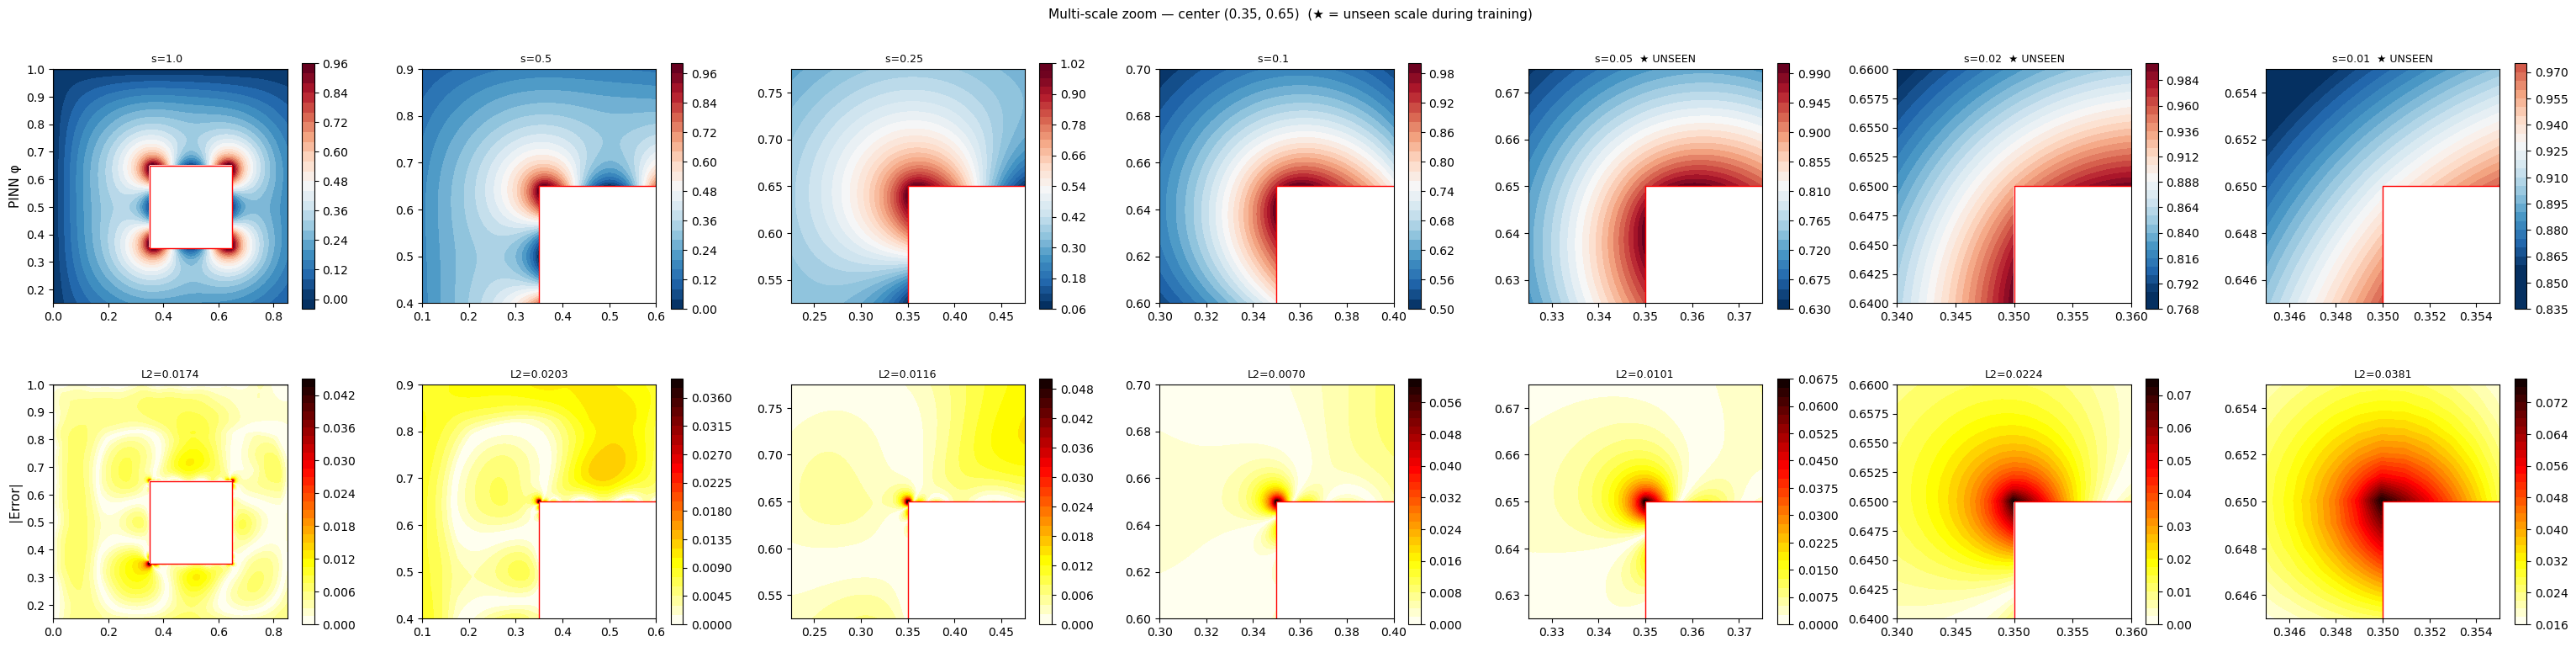

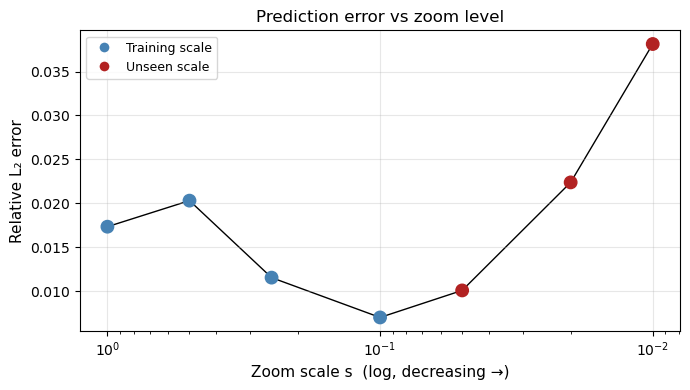

/var/folders/__/68q69_j51cj16zb24xlwg1kw0000gn/T/ipykernel_76956/1494731803.py:192: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  inside = contains(domain, pts_ray[:, 0], pts_ray[:, 1])


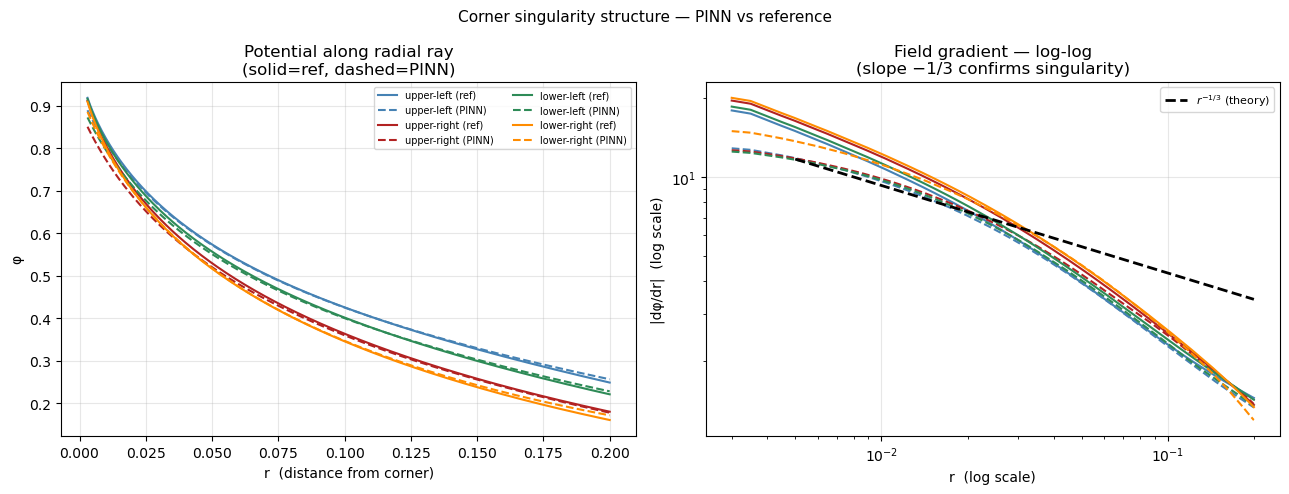


Evaluation complete.
Saved: eval_global.png, eval_zoom_panels.png, eval_error_vs_scale.png, eval_corner_singularity.png


In [12]:
model.eval()

def predict_grid(model, scale, center, N_eval=200):
    """
    Evaluate model on a regular grid within a zoom window.
    Returns XG, YG, phi_pred, phi_ref, error, l2_rel
    """
    cx, cy = center
    half   = scale / 2
    x0, x1 = max(0, cx - half), min(1, cx + half)
    y0, y1 = max(0, cy - half), min(1, cy + half)

    xg = np.linspace(x0, x1, N_eval)
    yg = np.linspace(y0, y1, N_eval)
    XG, YG = np.meshgrid(xg, yg, indexing='ij')
    pts    = np.stack([XG.ravel(), YG.ravel()], axis=1)


    inside = contains(domain, pts[:, 0], pts[:, 1])

    phi_pred = np.full(N_eval * N_eval, np.nan)
    phi_ref  = np.full(N_eval * N_eval, np.nan)

    if inside.any():
        pts_in = pts[inside]
        feats  = make_features(pts_in, scale=scale, center=center)
        with torch.no_grad():
            pred = model(to_tensor(feats)).cpu().numpy().squeeze()
        ref = phi_reference(pts_in)

        phi_pred[inside] = pred
        phi_ref[inside]  = ref

        l2 = (np.linalg.norm(pred - ref) /
              (np.linalg.norm(ref) + 1e-12))
    else:
        l2 = np.nan

    error = np.abs(phi_pred - phi_ref)
    return (XG, YG,
            phi_pred.reshape(N_eval, N_eval),
            phi_ref.reshape(N_eval, N_eval),
            error.reshape(N_eval, N_eval),
            l2)

print('Evaluating global prediction...')
XG, YG, pred_g, ref_g, err_g, l2_g = predict_grid(
    model, scale=1.0, center=(0.5, 0.5), N_eval=256
)
print(f'  Global relative L2 error: {l2_g:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
vmin, vmax_phi = np.nanmin(ref_g), np.nanmax(ref_g)

for ax, data, title in zip(axes,
    [pred_g, ref_g, err_g],
    ['PINN prediction',
     'FD reference',
     f'|Error|   L2={l2_g:.4f}']):
    if 'Error' in title:
        cf = ax.contourf(XG, YG, data, levels=40, cmap='hot_r')
    else:
        cf = ax.contourf(XG, YG, data, levels=40, cmap='RdBu_r',
                         vmin=vmin, vmax=vmax_phi)
    plt.colorbar(cf, ax=ax, label='φ')
    ax.plot(*np.array(outer    + [outer[0]]).T, 'k-', lw=1.5)
    ax.plot(*np.array(obstacle + [obstacle[0]]).T, 'r-', lw=1.5)
    ax.set_aspect('equal')
    ax.set_title(title)

plt.suptitle('Global evaluation — scale s=1.0', fontsize=11)
plt.tight_layout()
plt.savefig('ModelOutput/eval_global.png', dpi=150)
plt.show()

print('Evaluating zoom panels...')

zoom_center = (0.35, 0.65)
zoom_scales = [1.0, 0.5, 0.25, 0.1, 0.05, 0.02, 0.01]
zoom_results = {}
scale_errors = {}

for scale in zoom_scales:
    XG, YG, pred, ref, err, l2 = predict_grid(
        model, scale=scale, center=zoom_center
    )
    zoom_results[scale] = (XG, YG, pred, ref, err, l2)
    scale_errors[scale] = l2
    trained = '(train)' if scale in SCALES_TRAIN else '(UNSEEN)'
    print(f'  s={scale:.2f}  L2={l2:.4f}  {trained}')

# Plot — 2 rows (pred, error) × 5 scales
n_scales = len(zoom_scales)
fig, axes = plt.subplots(2, n_scales, figsize=(4.4 * n_scales, 8))

for col, scale in enumerate(zoom_scales):
    XG, YG, pred, ref, err, l2 = zoom_results[scale]
    vmin_s = np.nanmin(ref); vmax_s = np.nanmax(ref)

    ax = axes[0, col]
    cf = ax.contourf(XG, YG, pred, levels=30,
                     cmap='RdBu_r', vmin=vmin_s, vmax=vmax_s)
    plt.colorbar(cf, ax=ax, shrink=0.8)
    ax.plot(*np.array(outer    + [outer[0]]).T, 'k-', lw=1)
    ax.plot(*np.array(obstacle + [obstacle[0]]).T, 'r-', lw=1)
    ax.set_xlim(XG.min(), XG.max()); ax.set_ylim(YG.min(), YG.max())
    ax.set_aspect('equal')
    label = '★ UNSEEN' if scale not in SCALES_TRAIN else ''
    ax.set_title(f's={scale}  {label}', fontsize=9)


    ax = axes[1, col]
    cf = ax.contourf(XG, YG, err, levels=30, cmap='hot_r')
    plt.colorbar(cf, ax=ax, shrink=0.8)
    ax.plot(*np.array(outer    + [outer[0]]).T, 'k-', lw=1)
    ax.plot(*np.array(obstacle + [obstacle[0]]).T, 'r-', lw=1)
    ax.set_xlim(XG.min(), XG.max()); ax.set_ylim(YG.min(), YG.max())
    ax.set_aspect('equal')
    ax.set_title(f'L2={l2:.4f}' if not np.isnan(l2) else 'L2=N/A',
                 fontsize=9)

axes[0, 0].set_ylabel('PINN φ', fontsize=11)
axes[1, 0].set_ylabel('|Error|', fontsize=11)
plt.suptitle(f'Multi-scale zoom — center {zoom_center}  '
             f'(★ = unseen scale during training)', fontsize=11)
plt.tight_layout()
plt.savefig('ModelOutput/eval_zoom_panels.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))

scales_list = list(scale_errors.keys())
errors_list = list(scale_errors.values())
colors_list = ['steelblue' if s in SCALES_TRAIN else 'firebrick'
               for s in scales_list]

ax.plot(scales_list, errors_list, 'k-', lw=1, zorder=1)
ax.scatter(scales_list, errors_list, c=colors_list, s=80, zorder=2)


from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='steelblue', markersize=8, label='Training scale'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='firebrick', markersize=8, label='Unseen scale'),
]
ax.legend(handles=legend_elements, fontsize=9)

ax.set_xscale('log')
ax.invert_xaxis()
ax.set_xlabel('Zoom scale s  (log, decreasing →)', fontsize=11)
ax.set_ylabel('Relative L₂ error', fontsize=11)
ax.set_title('Prediction error vs zoom level')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ModelOutput/eval_error_vs_scale.png', dpi=150)
plt.show()

from scipy.optimize import curve_fit

corners = {
    'upper-left':  (0.35, 0.65),
    'upper-right': (0.65, 0.65),
    'lower-left':  (0.35, 0.35),
    'lower-right': (0.65, 0.35),
}
directions = {
    'upper-left':  (-1,  1),
    'upper-right': ( 1,  1),
    'lower-left':  (-1, -1),
    'lower-right': ( 1, -1),
}
colors_c = ['steelblue', 'firebrick', 'seagreen', 'darkorange']

r_vals = np.linspace(0.003, 0.20, 400)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for (name, corner), (_, direction), color in zip(
        corners.items(), directions.items(), colors_c):

    cx, cy = corner
    dx, dy = np.array(direction, dtype=float)
    norm   = np.sqrt(dx**2 + dy**2)
    dx, dy = dx / norm, dy / norm

    xs_ray = cx + r_vals * dx
    ys_ray = cy + r_vals * dy
    pts_ray = np.stack([xs_ray, ys_ray], axis=1)

    from shapely.vectorized import contains
    inside = contains(domain, pts_ray[:, 0], pts_ray[:, 1])
    r_in   = r_vals[inside]
    pts_in = pts_ray[inside]

    if len(r_in) < 20:
        continue


    phi_ref_ray = phi_reference(pts_in)

    
    feats = make_features(pts_in, scale=0.1, center=corner)
    with torch.no_grad():
        phi_pred_ray = model(
            to_tensor(feats)
        ).cpu().numpy().squeeze()

    dphi_dr_ref  = np.gradient(phi_ref_ray,  r_in)
    dphi_dr_pred = np.gradient(phi_pred_ray, r_in)

    axes[0].plot(r_in, phi_ref_ray,  color=color, lw=1.5,
                 ls='-',  label=f'{name} (ref)')
    axes[0].plot(r_in, phi_pred_ray, color=color, lw=1.5,
                 ls='--', label=f'{name} (PINN)')

    axes[1].loglog(r_in, np.abs(dphi_dr_ref),  color=color, lw=1.5, ls='-')
    axes[1].loglog(r_in, np.abs(dphi_dr_pred), color=color, lw=1.5, ls='--')

r_th = np.linspace(0.005, 0.20, 200)
axes[1].loglog(r_th, 2.0 * r_th**(-1/3), 'k--', lw=2,
               label=r'$r^{-1/3}$ (theory)')

axes[0].set_xlabel('r  (distance from corner)')
axes[0].set_ylabel('φ')
axes[0].set_title('Potential along radial ray\n(solid=ref, dashed=PINN)')
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('r  (log scale)')
axes[1].set_ylabel('|dφ/dr|  (log scale)')
axes[1].set_title('Field gradient — log-log\n(slope −1/3 confirms singularity)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Corner singularity structure — PINN vs reference', fontsize=11)
plt.tight_layout()
plt.savefig('ModelOutput/eval_corner_singularity.png', dpi=150)
plt.show()

print('\nEvaluation complete.')
print('Saved: eval_global.png, eval_zoom_panels.png, '
      'eval_error_vs_scale.png, eval_corner_singularity.png')